In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 3000

screen_time = np.random.randint(1,13,n)
social_media = np.random.randint(0,8,n)
gaming_hours = np.random.randint(0,6,n)
notifications = np.random.randint(10,300,n)
sleep_hours = np.random.randint(4,10,n)

addiction = []

for i in range(n):

    score = (
        screen_time[i]*2
        + social_media[i]*2
        + gaming_hours[i]*1.5
        + notifications[i]/50
        - sleep_hours[i]
    )

    if score >= 18:
        addiction.append("Addicted")
    else:
        addiction.append("Not Addicted")

df = pd.DataFrame({
    "Screen_Time_Hours":screen_time,
    "Social_Media_Hours":social_media,
    "Gaming_Hours":gaming_hours,
    "Notifications_Per_Day":notifications,
    "Sleep_Hours":sleep_hours,
    "Addiction":addiction
})

df.to_csv("smartphone_addiction.csv",index=False)

print(df.shape)
df.head()

(3000, 6)


,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Notifications_Per_Day,Sleep_Hours,Addiction
0,7,5,3,98,8,Addicted
1,4,3,3,261,6,Not Addicted
2,11,3,5,81,5,Addicted
3,8,3,5,174,9,Addicted
4,5,0,2,58,9,Not Addicted


In [2]:
df["Addiction"].value_counts()

,count
Addiction,
Addicted,1740
Not Addicted,1260


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Screen_Time_Hours      3000 non-null   int64 
 1   Social_Media_Hours     3000 non-null   int64 
 2   Gaming_Hours           3000 non-null   int64 
 3   Notifications_Per_Day  3000 non-null   int64 
 4   Sleep_Hours            3000 non-null   int64 
 5   Addiction              3000 non-null   object
dtypes: int64(5), object(1)
memory usage: 140.8+ KB


In [4]:
df.describe()

,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Notifications_Per_Day,Sleep_Hours
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,6.423667,3.462333,2.517667,155.469333,6.556000
std,3.472011,2.283342,1.704305,83.695010,1.696218
min,1.000000,0.000000,0.000000,10.000000,4.000000
25%,3.000000,2.000000,1.000000,83.000000,5.000000
50%,6.000000,3.000000,3.000000,155.000000,7.000000
75%,9.000000,5.000000,4.000000,228.000000,8.000000
max,12.000000,7.000000,5.000000,299.000000,9.000000


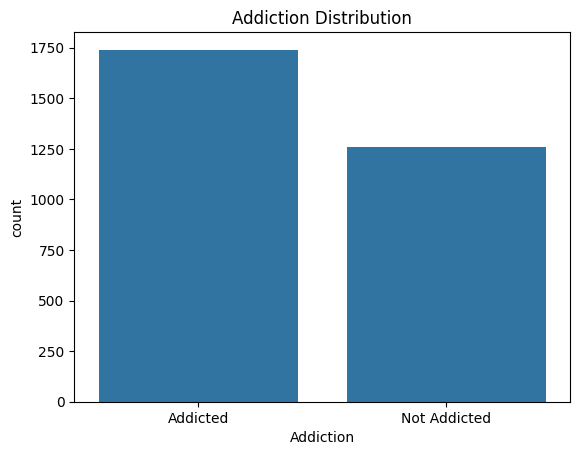

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Addiction')

plt.title('Addiction Distribution')
plt.show()

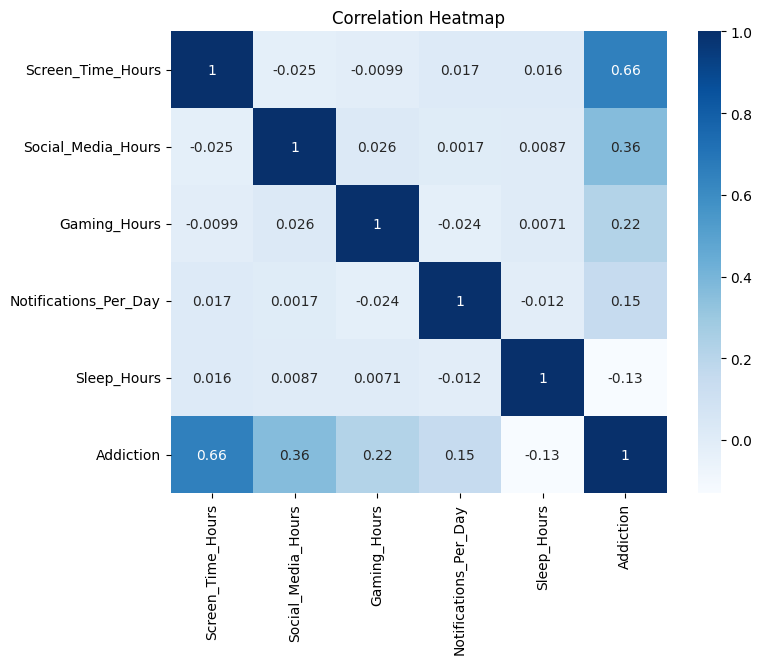

In [6]:
temp = df.copy()

temp["Addiction"] = temp["Addiction"].map({
    "Not Addicted": 0,
    "Addicted": 1
})

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

In [7]:
df["Addiction"] = df["Addiction"].map({
    "Not Addicted":0,
    "Addicted":1
})

In [8]:
X = df.drop("Addiction", axis=1)

y = df["Addiction"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (2400, 5)
Testing Data: (600, 5)


In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Accuracy : 0.9533333333333334
Precision: 0.9648093841642229
Recall   : 0.9536231884057971
F1 Score : 0.9591836734693877

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       255
           1       0.96      0.95      0.96       345

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600



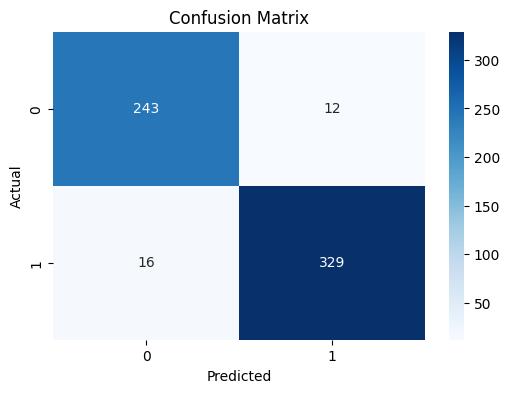

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
import pickle

pickle.dump(
    model,
    open("addiction_classifier.pkl","wb")
)

In [16]:
import os
print(os.listdir())

['.config', 'smartphone_addiction.csv', 'addiction_classifier.pkl', 'sample_data']
